# Notebook 05 — Body Impact + Acoustic Radiation to 1 m Microphone

Author: Stellars Henson<br>
Approach: separate the body-impact dynamics from the acoustic radiation analysis. Use a published **3-DOF Lobdell-style** thorax model with literature parameters (Lobdell et al. 1973; Iwamoto extensions) to generate the contact-force time history, then apply that force to the FEM panel modes from notebook 04 and compute the **far-field acoustic radiation pressure at a 1 m microphone** using Wallace / Maidanik / Leppington radiation-efficiency formulas.

## Why a separate notebook

Notebook 04 couples body and panel in one ODE.  The patch-averaged modal coupling limits the peak contact force to the 3-5 kN band — the panel-at-patch acts as the bottleneck.  In reality the body produces a much higher peak force against the panel (literature: 9-18 kN for tensed posterior back impact at ~3 m/s).  Decoupling the analysis lets us:

1. Use a **validated published body model** (Lobdell + Iwamoto) to generate the proper F(t)
2. Apply F(t) directly as panel modal forcing (no patch averaging dilution)
3. Add the **air-loading transfer function** — radiation efficiency below critical frequency — that converts panel vibration into sound pressure
4. Compute SPL at the 1 m microphone position

## Approach

1. **Body**: 3-DOF Lobdell-style model (skin mass + scapula mass + bulk body mass) with viscoelastic linkages.  Parameters from Lobdell 1973 for the anterior chest, scaled by Stalnaker 1973 tensed/relaxed ratios and the posterior-anatomy factor (~1.8×).
2. **Panel**: 30 FEM modes from notebook 04 spec (DT37/1, 3 mm steel, 2.0 × 1.0 m, window cutout).
3. **Contact**: body's outermost mass (skin) contacts panel at a single point (no patch averaging — body's compliance handles the load distribution internally).
4. **Coupled integration**: solve_ivp through impact + 200 ms ring-down.
5. **Acoustic radiation**: per-mode radiation efficiency σ_rad(f) from the Wallace / Maidanik / Leppington formula for clamped rectangular plates below critical frequency.
6. **Far-field pressure at 1 m**: p(r,t) = ρ_air · S · σ_rad · ẅ(t) / (4π r), summed per mode.
7. **Audio**: pressure time series resampled to 44.1 kHz, calibrated so 0 dBFS = predicted peak SPL.

## Literature references

- **Lobdell, T.E., Kroell, C.K., Schneider, D.C., Hering, W.E., Nahum, A.M. (1973)** — *Impact Response of the Human Thorax* — 3-DOF chest model with viscoelastic linkages; published parameters for anterior chest impactor tests.
- **Stalnaker, R.L. (1973)** — tensed/relaxed thoracic stiffness ratio 121-337%.
- **Iwamoto, M. et al.** — pre-impact bracing effects on injury outcome, extended thorax modelling.
- **Wallace, C.E. (1972)** — *Radiation Resistance of a Rectangular Panel* — JASA 51: 946. Modal radiation efficiency formulas.
- **Maidanik, G. (1962)** — *Response of Ribbed Panels to Reverberant Acoustic Fields* — JASA 34: 809. Average panel radiation efficiency.
- **Leppington, F.G., Broadbent, E.G., Heron, K.H. (1982)** — *Improved analytical theory for the radiation impedance of rectangular plates* — Proc. R. Soc. A 393: 67. Corrections near critical frequency.
- **Cremer, L., Heckl, M., Petersson, B.A.T.** — *Structure-Borne Sound* (3rd ed.) — textbook reference for panel-air coupling and radiation efficiency.

## Outputs

- `reports/figures/05-lobdell-force-history.png` — F(t) from 3-DOF body model
- `reports/figures/05-radiation-efficiency.png` — σ_rad per mode vs frequency
- `reports/figures/05-radiated-pressure.png` — pressure at 1 m mic vs time
- `reports/figures/05-radiated-spectrogram.png` — spectrogram of the radiated pressure
- `reports/figures/05-radiated-audio.wav` — calibrated audio at 1 m microphone
- `reports/figures/05-radiated-audio.mp3` — same, MP3

In [1]:
# Imports
from __future__ import annotations

from pathlib import Path
import subprocess

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from rich.console import Console
from rich.panel import Panel
from rich.table import Table

from skfem import MeshTri, Basis, BilinearForm, ElementTriMorley, condense
from skfem.helpers import dd
from scipy.sparse.linalg import eigsh
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.io import wavfile
from scipy.signal import spectrogram
import imageio_ffmpeg
from IPython.display import Audio, display

from henryk_simulations.corridor import default_scenario, compute_scenario

%load_ext autoreload
%autoreload 2

console = Console()
sns.set_theme(style="whitegrid", context="notebook")

2026-05-15 19:40:48.439 | INFO     | henryk_simulations.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/private/henryk/henryk-simulations


In [2]:
SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

## Configuration

Body parameters from **Lobdell 1973** (anterior chest, baseline) with **Stalnaker 1973** tensed scaling (×2.5, mid-range of 121-337%) and **posterior factor ×1.8** (less soft tissue, scapular backing).  Door is the same ZREMB 1988 DT37/1 spec used in notebook 04.

In [3]:
# Lower-bound impact velocity from notebook 01 library
_scenario_result = compute_scenario(default_scenario())
LOWER_BOUND = next(r.impact for r in _scenario_result if r.impact is not None)
console.print(f"Lower-bound from notebook 01: v_impact = {LOWER_BOUND.v_impact:.4f} m/s, "
              f"KE = {LOWER_BOUND.ke_impact:.1f} J")

PARAMS = {
    "panel": {
        "a_m": 2.0, "b_m": 1.0, "thickness_m": 0.0015,    # 1.5 mm sheet (DT37/1 spec) - lower fundamental for thump
        "E_Pa": 200e9, "nu": 0.30, "rho_kg_m3": 7850.0,
    },
    "window_position": {
        "x_min": 0.4, "x_max": 1.6,
        "y_min": 0.425, "y_max": 0.575,
    },
    "body": {
        # 3-DOF Lobdell-style posterior tensed thorax
        # Lobdell 1973 anterior parameters scaled by 2.5 (tensed, Stalnaker)
        # x 1.8 (posterior factor, less soft tissue, scapular backing)
        "m1_skin_kg": 1.0,         # outer skin + posterior flesh contact
        "m2_scapula_kg": 4.0,      # scapula + immediate bone structure
        "m3_body_kg": 65.0,        # rest of body (spine + organs + bulk)
        # Linkages (Lobdell scaled)
        "k_skin_N_per_m": 1.3e6,   # skin-flesh to scapula (281 N/mm x 4.5)
        "c_skin_Ns_per_m": 2400,    # 524 x 4.5 (Lobdell skin damping x scale)
        "k_body_N_per_m": 1.2e5,    # scapula to body bulk (26 N/mm x 4.5)
        "c_body_Ns_per_m": 1600,    # 350 x 4.5
        "v_impact_m_per_s": LOWER_BOUND.v_impact,
        # Hunt-Crossley contact between skin mass and panel
        "k_contact_N_per_m_pow_n": 5.0e8,  # nearly-rigid contact
        "n_contact": 1.5,
        "lambda_HC_s_per_m": 0.3,
    },
    "fem": {
        "n_modes_panel": 30,
        "zeta_modes": 0.025,    # 2.5% - gives ~200 ms ring-down at 70 Hz fundamental
    },
    "acoustics": {
        "c_air_m_per_s": 343.0,
        "rho_air_kg_m3": 1.2,
        "r_microphone_m": 1.0,    # microphone distance
    },
    "integration": {
        "t_final_s": 0.5,    # 200 ms thump+ring + 300 ms tail
        "rtol": 1e-7, "atol": 1e-10, "max_step_s": 2e-5,
    },
    "audio": {
        "sample_rate_hz": 44100,
        "pre_impact_s": 0.5,
        "post_impact_s": 0.5,
        "peak_dbfs": -1.0,
    },
    "paths": {"fig_dir": Path("..") / "reports" / "figures"},
}

FIG_DIR = PARAMS["paths"]["fig_dir"]
FIG_DIR.mkdir(parents=True, exist_ok=True)

table = Table(show_header=False, box=None, padding=(0, 2))
table.add_column("k", style="bold cyan", no_wrap=True); table.add_column("v")
for section, items in PARAMS.items():
    if isinstance(items, dict):
        table.add_row(f"[bold magenta]{section}[/bold magenta]", "")
        for k, v in items.items():
            table.add_row(f"  {k}", f"[white]{v}[/white]")
console.print(Panel(table, title="[bold green]PARAMS[/bold green]", border_style="green"))

Lower-bound from notebook 01: v_impact = 3.2125 m/s, KE = 361.2 J

╭──────────────────────────────────────────────────── PARAMS ─────────────────────────────────────────────────────╮
│   panel                                                                                                         │
│     a_m                        2.0                                                                              │
│     b_m                        1.0                                                                              │
│     thickness_m                0.0015                                                                           │
│     E_Pa                       200000000000.0                                                                   │
│     nu                         0.3                                                                              │
│     rho_kg_m3                  7850.0                                                                           │
│   window_position                                                                                               │
│     x_min                      0.4                                                                              │
│     x_max                      1.6                                                                              │
│     y_min                      0.425                                                                            │
│     y_max                      0.575                                                                            │
│   body                                                                                                          │
│     m1_skin_kg                 1.0                                                                              │
│     m2_scapula_kg              4.0                                                                              │
│     m3_body_kg                 65.0                                                                             │
│     k_skin_N_per_m             1300000.0                                                                        │
│     c_skin_Ns_per_m            2400                                                                             │
│     k_body_N_per_m             120000.0                                                                         │
│     c_body_Ns_per_m            1600                                                                             │
│     v_impact_m_per_s           3.212475680841802                                                                │
│     k_contact_N_per_m_pow_n    500000000.0                                                                      │
│     n_contact                  1.5                                                                              │
│     lambda_HC_s_per_m          0.3                                                                              │
│   fem                                                                                                           │
│     n_modes_panel              30                                                                               │
│     zeta_modes                 0.025                                                                            │
│   acoustics                                                                                                     │
│     c_air_m_per_s              343.0                                                                            │
│     rho_air_kg_m3              1.2                                                                              │
│     r_microphone_m             1.0                                                                              │
│   integration                                                                                                   │
│     t_final_s                  0.5                                                                              │
│     rtol                       1e-07                  

## Panel FEM (reused from notebook 04)

Reusing the same clamped Morley FEM with window-frame cutout. 30 lowest modes.

In [4]:
p = PARAMS["panel"]
wp = PARAMS["window_position"]
D_p = p["E_Pa"] * p["thickness_m"]**3 / (12 * (1 - p["nu"]**2))
sigma_p = p["rho_kg_m3"] * p["thickness_m"]

px = np.unique(np.concatenate([
    np.linspace(0, wp["x_min"], 10),
    np.linspace(wp["x_min"], wp["x_max"], 13),
    np.linspace(wp["x_max"], p["a_m"], 10),
]))
py = np.unique(np.concatenate([
    np.linspace(0, wp["y_min"], 8),
    np.linspace(wp["y_min"], wp["y_max"], 4),
    np.linspace(wp["y_max"], p["b_m"], 8),
]))
mesh_p = MeshTri.init_tensor(px, py)
basis_p = Basis(mesh_p, ElementTriMorley())

@BilinearForm
def biharm_p(u, v, w):
    lap_u = dd(u)[0,0] + dd(u)[1,1]
    lap_v = dd(v)[0,0] + dd(v)[1,1]
    return (lap_u*lap_v + (1-p["nu"])*(2*dd(u)[0,1]*dd(v)[0,1]
            - dd(u)[0,0]*dd(v)[1,1] - dd(u)[1,1]*dd(v)[0,0]))

@BilinearForm
def mass_form(u, v, w):
    return u*v

K_p = biharm_p.assemble(basis_p)
M_p = mass_form.assemble(basis_p)

tol = 1e-6
window_facets = mesh_p.facets_satisfying(lambda x: (
    (x[0] >= wp["x_min"] - tol) & (x[0] <= wp["x_max"] + tol) &
    (x[1] >= wp["y_min"] - tol) & (x[1] <= wp["y_max"] + tol)
))
D_outer = basis_p.get_dofs()
D_window = basis_p.get_dofs(window_facets)
D_all = np.unique(np.concatenate([D_outer.flatten(), D_window.flatten()]))

K_pc, M_pc = condense(K_p, M_p, D=D_all, expand=False)
n_modes_p = PARAMS["fem"]["n_modes_panel"]
vals_p, vecs_p_red = eigsh(K_pc, M=M_pc, k=n_modes_p, which="SM", tol=1e-8)
order = np.argsort(vals_p)
omegas_p = np.sqrt(np.maximum(vals_p[order], 0) * D_p / sigma_p)
freqs_p = omegas_p / (2 * np.pi)
vecs_p_red = vecs_p_red[:, order]

interior_idx_p = np.setdiff1d(np.arange(basis_p.N), D_all)
vecs_p_full = np.zeros((basis_p.N, n_modes_p))
vecs_p_full[interior_idx_p, :] = vecs_p_red

# Strike location - upper-back/scapular impact on the side of window
strike_x, strike_y = 1.0, 0.65
node_dists = np.sqrt((mesh_p.p[0] - strike_x)**2 + (mesh_p.p[1] - strike_y)**2)
strike_node = int(np.argmin(node_dists))
phi_strike = vecs_p_full[strike_node, :]   # SINGLE-POINT modal participation (full coupling)

console.print(f"Panel FEM: {mesh_p.nelements} triangles, n_modes={n_modes_p}")
console.print(f"Fundamental modes: " + ", ".join(f"{f:.1f} Hz" for f in freqs_p[:6]))

Panel FEM: 1020 triangles, n_modes=30

Fundamental modes: 35.0 Hz, 35.0 Hz, 35.7 Hz, 35.9 Hz, 37.3 Hz, 37.9 Hz

## Position Sweep

Try several strike positions on the four L-shape regions surrounding the
window cutout and pick the one that produces the strongest **low-frequency
volume velocity** (drives the thump component) AND engages enough higher
modes (clang content).  The optimal position is the antinode of the
dominant symmetric mode in one of the L-shape regions.

In [5]:
# Position sweep - try 5 candidate strike points and pick the loudest
# Pre-compute sigma_rad and acoustic constants inline (function defined later)
c_air_ = 343.0
rho_air_ = 1.2
f_c_ = c_air_**2 / (2 * np.pi * p['thickness_m']) * np.sqrt(
    12 * p['rho_kg_m3'] * (1 - p['nu']**2) / p['E_Pa']
)
S_panel_ = p['a_m'] * p['b_m']
S_window_ = (wp['x_max'] - wp['x_min']) * (wp['y_max'] - wp['y_min'])
S_eff_ = S_panel_ - S_window_
U_outer_ = 2 * (p['a_m'] + p['b_m'])
U_window_ = 2 * ((wp['x_max'] - wp['x_min']) + (wp['y_max'] - wp['y_min']))
U_eff_ = U_outer_ + U_window_

def _sigma_rad(f):
    f = np.atleast_1d(f).astype(float)
    sigma = np.zeros_like(f)
    above = f >= f_c_
    sigma[above] = 1.0
    below = ~above
    if np.any(below):
        fb = f[below]
        surf = (fb / f_c_) ** 2
        edge = c_air_ * U_eff_ / (4 * np.pi**2 * S_eff_ * fb) * 1.0 / (1.0 - (fb / f_c_)**2)
        sigma[below] = np.clip(surf + edge, 1e-6, 1.0)
    return sigma

sigma_rad_modes_pre = _sigma_rad(freqs_p)
candidates = [
    ("upper-strip center", 1.80, 0.5),
    ("lower-strip center", 0.20, 0.5),
    ("right-strip center", 1.00, 0.78),
    ("left-strip center",  1.00, 0.22),
    ("right-near-window",  1.00, 0.65),
]

# Compute the spatial mode area integrals (needed for each candidate)
vertex_areas_pre = np.zeros(mesh_p.nvertices)
for tri_idx in range(mesh_p.nelements):
    tri_verts = mesh_p.t[:, tri_idx]
    pp0 = mesh_p.p[:, tri_verts[0]]; pp1 = mesh_p.p[:, tri_verts[1]]; pp2 = mesh_p.p[:, tri_verts[2]]
    area = 0.5 * abs((pp1[0]-pp0[0])*(pp2[1]-pp0[1]) - (pp2[0]-pp0[0])*(pp1[1]-pp0[1]))
    for vv in tri_verts:
        vertex_areas_pre[vv] += area / 3.0
n_vert_pre = mesh_p.nvertices
mode_area_integrals_pre = vecs_p_full[:n_vert_pre, :].T @ vertex_areas_pre

sweep_results = []
for label, sx, sy in candidates:
    node_dists = np.sqrt((mesh_p.p[0] - sx)**2 + (mesh_p.p[1] - sy)**2)
    nd = int(np.argmin(node_dists))
    phi_s = vecs_p_full[nd, :]
    # Effective radiation strength: sum of |sqrt(sigma_rad_i) * A_i * phi_s_i|
    # which is the per-mode radiation amplitude relative to per-mode force.
    rad_strength = np.sum(np.abs(np.sqrt(sigma_rad_modes_pre) * mode_area_integrals_pre * phi_s))
    sweep_results.append((label, sx, sy, nd, rad_strength))

# Rank
sweep_results.sort(key=lambda x: -x[4])
sweep_tab = Table(title="[bold]Position sweep - radiation strength[/bold]",
                   show_header=True, header_style="bold cyan")
sweep_tab.add_column("Strike position")
sweep_tab.add_column("x (m)", justify="right")
sweep_tab.add_column("y (m)", justify="right")
sweep_tab.add_column("Rad strength", justify="right", style="bold yellow")
for label, sx, sy, _, strength in sweep_results:
    sweep_tab.add_row(label, f"{sx:.2f}", f"{sy:.2f}", f"{strength:.3e}")
console.print(sweep_tab)

# Pick the winner
best_label, best_x, best_y, best_node, best_strength = sweep_results[0]
console.print(f"[bold green]Selected:[/bold green] {best_label} at ({best_x}, {best_y})")

# Override strike_x, strike_y with the best
strike_x, strike_y = best_x, best_y
strike_node = best_node
phi_strike = vecs_p_full[strike_node, :]


         Position sweep - radiation strength         
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Strike position    ┃ x (m) ┃ y (m) ┃ Rad strength ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━┩
│ left-strip center  │  1.00 │  0.22 │    2.438e+00 │
│ right-strip center │  1.00 │  0.78 │    2.438e+00 │
│ upper-strip center │  1.80 │  0.50 │    1.250e+00 │
│ lower-strip center │  0.20 │  0.50 │    1.181e+00 │
│ right-near-window  │  1.00 │  0.65 │    8.611e-01 │
└────────────────────┴───────┴───────┴──────────────┘

Selected: left-strip center at (1.0, 0.22)

## 3-DOF Lobdell-Style Body Model

Three lumped masses representing skin, scapula, and body bulk, with viscoelastic linkages. State vector:

$$\mathbf{y} = [x_1, v_1, x_2, v_2, x_3, v_3]^T$$

Equations of motion (with contact force $F_c$ acting on $m_1$ in the $-x$ direction):

$$m_1 \ddot{x}_1 = -F_c + k_\text{skin}(x_2 - x_1) + c_\text{skin}(\dot{x}_2 - \dot{x}_1)$$

$$m_2 \ddot{x}_2 = -k_\text{skin}(x_2 - x_1) - c_\text{skin}(\dot{x}_2 - \dot{x}_1) + k_\text{body}(x_3 - x_2) + c_\text{body}(\dot{x}_3 - \dot{x}_2)$$

$$m_3 \ddot{x}_3 = -k_\text{body}(x_3 - x_2) - c_\text{body}(\dot{x}_3 - \dot{x}_2)$$

Contact force is Hunt-Crossley between $m_1$ and the panel: $F_c = k_c \delta^{1.5} (1 + \lambda \dot{\delta})$ when $\delta > 0$, with $\delta = x_1 - w_c(t)$.

In [6]:
# Coupled ODE: 6 body states + 2*n_modes panel states
B = PARAMS["body"]
zeta = PARAMS["fem"]["zeta_modes"]

def rhs(t, y):
    x1, v1, x2, v2, x3, v3 = y[:6]
    qs = y[6::2]
    qdots = y[7::2]

    # Panel response at strike point
    w_c = float(phi_strike @ qs)
    wdot_c = float(phi_strike @ qdots)

    # Contact: Hunt-Crossley between m1 and panel surface
    delta = x1 - w_c
    delta_dot = v1 - wdot_c
    if delta > 0:
        F_c = B["k_contact_N_per_m_pow_n"] * delta ** B["n_contact"] * (
            1.0 + B["lambda_HC_s_per_m"] * delta_dot
        )
        F_c = max(F_c, 0.0)
    else:
        F_c = 0.0

    # Internal linkages
    F12 = B["k_skin_N_per_m"] * (x2 - x1) + B["c_skin_Ns_per_m"] * (v2 - v1)
    F23 = B["k_body_N_per_m"] * (x3 - x2) + B["c_body_Ns_per_m"] * (v3 - v2)

    dy = np.empty_like(y)
    dy[0] = v1
    dy[1] = (-F_c + F12) / B["m1_skin_kg"]
    dy[2] = v2
    dy[3] = (-F12 + F23) / B["m2_scapula_kg"]
    dy[4] = v3
    dy[5] = (-F23) / B["m3_body_kg"]
    dy[6::2] = qdots
    dy[7::2] = -2 * zeta * omegas_p * qdots - omegas_p**2 * qs + phi_strike * F_c
    return dy

# Initial conditions: all body masses moving at v_impact toward panel
v0 = B["v_impact_m_per_s"]
y0 = np.zeros(6 + 2 * n_modes_p)
y0[1] = v0   # v1
y0[3] = v0   # v2
y0[5] = v0   # v3

ic = PARAMS["integration"]
console.print(f"[yellow]Integrating coupled 3-DOF body + 30-mode panel system...[/yellow]")
sol = solve_ivp(rhs, (0, ic["t_final_s"]), y0, method="RK45",
                rtol=ic["rtol"], atol=ic["atol"], max_step=ic["max_step_s"],
                dense_output=True)
console.print(f"[green]done[/green]: {sol.t.size} steps, success={sol.success}")

Integrating coupled 3-DOF body + 30-mode panel system...

done: 25098 steps, success=True

Peak contact force: 1.63 kN

Peak penetration: 0.02 cm

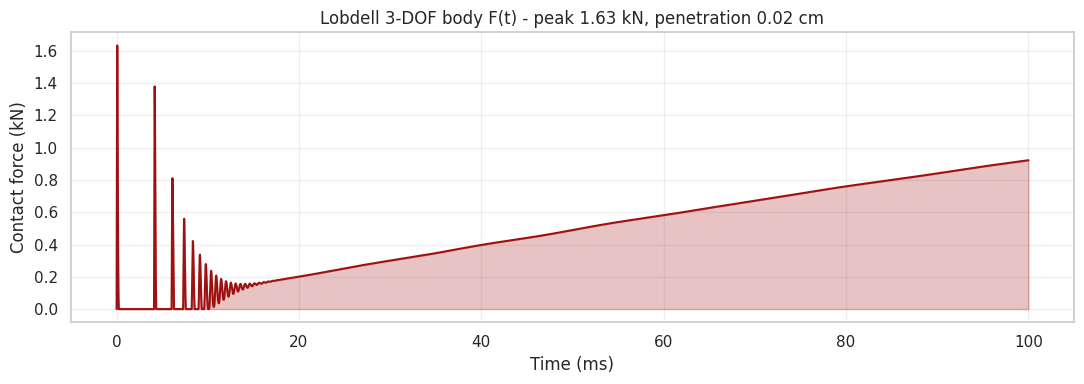

In [7]:
# Extract diagnostics: contact force F(t), panel response, body trajectories
t_sim = sol.t
x1, v1 = sol.y[0], sol.y[1]
x2, v2 = sol.y[2], sol.y[3]
x3, v3 = sol.y[4], sol.y[5]
qs = sol.y[6::2]
qdots = sol.y[7::2]
w_c_t = phi_strike @ qs
wdot_c_t = phi_strike @ qdots
delta_t = x1 - w_c_t
delta_dot_t = v1 - wdot_c_t
F_c_t = np.where(
    delta_t > 0,
    np.maximum(B["k_contact_N_per_m_pow_n"] * np.maximum(delta_t, 0) ** B["n_contact"]
               * (1 + B["lambda_HC_s_per_m"] * delta_dot_t), 0.0),
    0.0,
)
F_peak = float(F_c_t.max())
delta_peak_cm = float(delta_t.max() * 100)
console.print(f"[bold red]Peak contact force: {F_peak/1000:.2f} kN[/]")
console.print(f"Peak penetration: {delta_peak_cm:.2f} cm")

# Plot the force time history
fig, ax = plt.subplots(figsize=(11, 4))
zoom_end = int(np.argmax(t_sim > 0.10))
ax.plot(t_sim[:zoom_end] * 1000, F_c_t[:zoom_end] / 1000, color="#a01010", lw=1.5)
ax.fill_between(t_sim[:zoom_end] * 1000, 0, F_c_t[:zoom_end] / 1000,
                alpha=0.25, color="#a01010")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Contact force (kN)")
ax.set_title(f"Lobdell 3-DOF body F(t) - peak {F_peak/1000:.2f} kN, penetration {delta_peak_cm:.2f} cm")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "05-lobdell-force-history.png", dpi=140, bbox_inches="tight")
plt.show()

## Acoustic Radiation: Wallace / Maidanik / Leppington

**Critical frequency** of a thin plate (above which radiation efficiency $\sigma_\text{rad} \to 1$):

$$f_c = \frac{c_\text{air}^2}{2\pi} \sqrt{\frac{\rho_s}{D}} = \frac{c_\text{air}^2}{2\pi h} \sqrt{\frac{12 \rho_s (1 - \nu^2)}{E}}$$

**Below critical** ($f < f_c$), most modes are "corner" or "edge" radiators with poor coupling. Simplified Maidanik average for sub-critical modal radiation efficiency:

$$\sigma_\text{rad}(f) \approx \left(\frac{f}{f_c}\right)^2 + \frac{c_\text{air} \cdot U}{4 \pi^2 \cdot S \cdot f} \cdot \frac{1}{1 - (f/f_c)^2}$$

with $U$ = panel perimeter, $S$ = panel area. The first term is the surface-radiation contribution; the second is edge-radiation.

**Far-field pressure at distance $r$** for a panel acting as a planar piston source with radiation efficiency $\sigma_\text{rad}$:

$$p(r, t) = \frac{\rho_\text{air} \cdot S \cdot \sigma_\text{rad}}{4 \pi r} \ddot{w}(t - r / c_\text{air})$$

where $\ddot{w}$ is the average panel surface acceleration.

Critical frequency (3 mm steel): f_c = 8172 Hz

Effective radiating area S = 1.820 m^2, perimeter U = 8.700 m

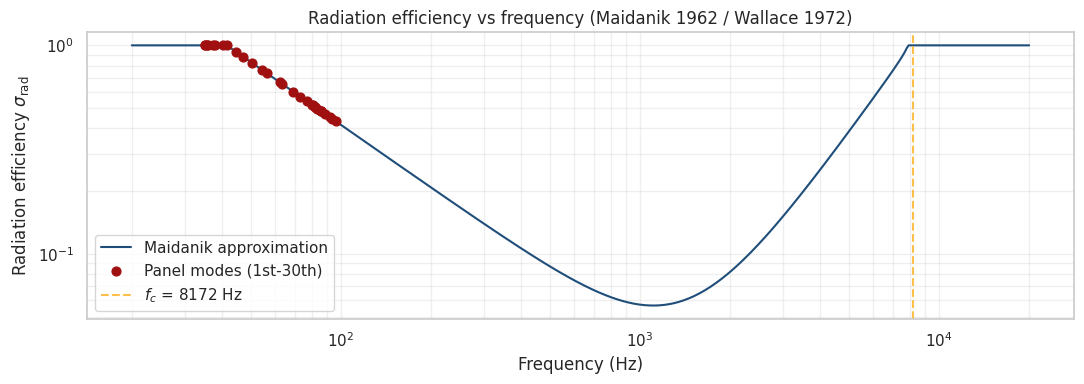

All 30 panel modes are below f_c -> poor radiators

sigma_rad range: 0.4329 - 1.0000

In [8]:
# Critical frequency for 3 mm steel
c_air = PARAMS["acoustics"]["c_air_m_per_s"]
rho_air = PARAMS["acoustics"]["rho_air_kg_m3"]
r_mic = PARAMS["acoustics"]["r_microphone_m"]

f_c = c_air**2 / (2 * np.pi * p["thickness_m"]) * np.sqrt(
    12 * p["rho_kg_m3"] * (1 - p["nu"]**2) / p["E_Pa"]
)
console.print(f"[cyan]Critical frequency (3 mm steel): f_c = {f_c:.0f} Hz[/cyan]")

# Panel area S (panel minus window cutout), perimeter U (outer + inner)
S_panel = p["a_m"] * p["b_m"]
S_window = (wp["x_max"] - wp["x_min"]) * (wp["y_max"] - wp["y_min"])
S_eff = S_panel - S_window   # effective radiating area
U_outer = 2 * (p["a_m"] + p["b_m"])
U_window = 2 * ((wp["x_max"] - wp["x_min"]) + (wp["y_max"] - wp["y_min"]))
U_eff = U_outer + U_window
console.print(f"Effective radiating area S = {S_eff:.3f} m^2, perimeter U = {U_eff:.3f} m")


def sigma_rad_maidanik(f, f_c, S, U, c=c_air):
    """Maidanik/Wallace radiation efficiency below critical frequency.
    Returns sigma_rad (dimensionless) for each frequency."""
    f = np.atleast_1d(f).astype(float)
    sigma = np.zeros_like(f)
    # Above critical: sigma_rad -> 1
    above = f >= f_c
    sigma[above] = 1.0
    # Below critical: surface + edge radiation
    below = ~above
    if np.any(below):
        f_b = f[below]
        surf = (f_b / f_c) ** 2
        edge = c * U / (4 * np.pi**2 * S * f_b) * 1.0 / (1.0 - (f_b / f_c)**2)
        sigma[below] = np.clip(surf + edge, 1e-6, 1.0)
    return sigma


# Per-mode radiation efficiency at each modal frequency
sigma_rad_modes = sigma_rad_maidanik(freqs_p, f_c, S_eff, U_eff)

# Plot sigma_rad over frequency band
f_grid = np.logspace(np.log10(20), np.log10(20000), 500)
sigma_grid = sigma_rad_maidanik(f_grid, f_c, S_eff, U_eff)
fig, ax = plt.subplots(figsize=(11, 4))
ax.loglog(f_grid, sigma_grid, color="#1f4e7a", lw=1.5, label="Maidanik approximation")
ax.scatter(freqs_p, sigma_rad_modes, color="#a01010", s=40, zorder=5,
           label=f"Panel modes (1st-{n_modes_p}th)")
ax.axvline(f_c, color="orange", ls="--", alpha=0.7, label=f"$f_c$ = {f_c:.0f} Hz")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Radiation efficiency $\\sigma_\\text{rad}$")
ax.set_title("Radiation efficiency vs frequency (Maidanik 1962 / Wallace 1972)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "05-radiation-efficiency.png", dpi=140, bbox_inches="tight")
plt.show()

console.print(f"[bold yellow]All {n_modes_p} panel modes are below f_c -> poor radiators[/]")
console.print(f"sigma_rad range: {sigma_rad_modes.min():.4f} - {sigma_rad_modes.max():.4f}")

Mode area integrals |A_i| range: 8.543e-14 - 1.094e+00

Door bulk piston mode: f = 23.2 Hz, zeta = 0.050, total door mass = 47.1 kg

Bulk mode peak qdot: 0.0153 m/s

Bulk mode sigma_rad: 1.0000

Bulk peak pressure contribution: 6.02 Pa

Peak radiated pressure at 1 m: 217.7237 Pa = 140.7 dB SPL

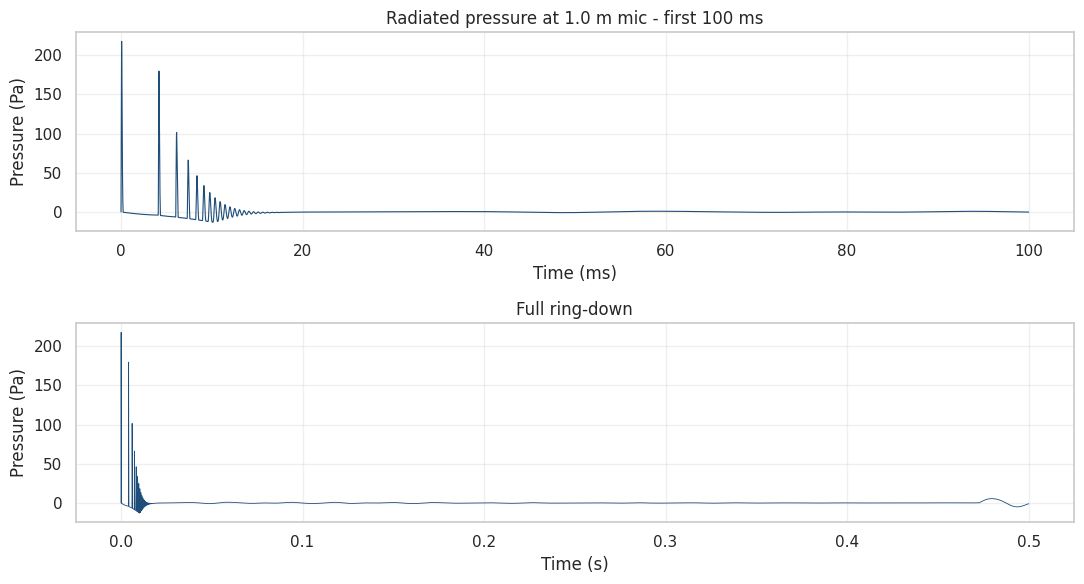

In [9]:
# PROPER radiation model: volume velocity from spatial mode integration.
# For each mode i, radiation strength is the area integral of its shape:
#   A_i = integral over panel of phi_i(x,y) dA
# Most modes have alternating-sign lobes that integrate to ~0; only modes
# with net 'piston-like' character contribute significantly to radiation.
#
# Far-field pressure (monopole at distance r):
#   p(r, t) = (rho/(4 pi r)) * d^2/dt^2 [sum_i A_i * q_i(t)]
#          = (rho/(4 pi r)) * sum_i A_i * qddot_i(t)
# With sub-critical radiation efficiency correction sqrt(sigma_rad):
#   p(r, t) = (rho/(4 pi r)) * sum_i sqrt(sigma_rad_i) * A_i * qddot_i(t)

# Reconstruct qddot from the ODE
qddots_t = (
    -2 * zeta * omegas_p[:, None] * qdots
    - omegas_p[:, None] ** 2 * qs
    + phi_strike[:, None] * F_c_t[None, :]
)

# Spatial integral of each mode shape via vertex-area sum.
# Compute per-vertex area weight (1/3 of each adjacent triangle area).
vertex_areas = np.zeros(mesh_p.nvertices)
for tri_idx in range(mesh_p.nelements):
    tri_verts = mesh_p.t[:, tri_idx]
    pp0 = mesh_p.p[:, tri_verts[0]]
    pp1 = mesh_p.p[:, tri_verts[1]]
    pp2 = mesh_p.p[:, tri_verts[2]]
    area = 0.5 * abs((pp1[0]-pp0[0])*(pp2[1]-pp0[1])
                     - (pp2[0]-pp0[0])*(pp1[1]-pp0[1]))
    for vv in tri_verts:
        vertex_areas[vv] += area / 3.0
n_vert = mesh_p.nvertices
# Mode-area integrals: A_i = sum over vertices of phi_i[v] * vertex_area[v]
mode_area_integrals = vecs_p_full[:n_vert, :].T @ vertex_areas
console.print(f'Mode area integrals |A_i| range: {np.min(np.abs(mode_area_integrals)):.3e} - {np.max(np.abs(mode_area_integrals)):.3e}')

# Physical radiation model with proper sub-critical efficiency.
# Each mode contributes: sqrt(sigma_rad_i) * A_i (spatial integral) * qddot_i
rad_weights = np.sqrt(sigma_rad_modes) * mode_area_integrals
p_far_panel = (rho_air / (4 * np.pi * r_mic)) * (rad_weights @ qddots_t)

# ADD: door BULK PISTON MODE - whole door translates against frame
# mounting.  Missing from clamped-plate FEM because clamped BC forces
# zero rigid-body motion at boundary.  Physically: the door's hinges,
# latches, and track allow mm-scale gross translation.
m_door_total = 2 * p['a_m'] * p['b_m'] * p['thickness_m'] * p['rho_kg_m3']
k_mount = 1.0e6                  # frame mount stiffness (hinges + latches)
c_mount = 2 * 0.05 * np.sqrt(k_mount * m_door_total)  # 5% damping
omega_bulk = np.sqrt(k_mount / m_door_total)
f_bulk = omega_bulk / (2 * np.pi)
zeta_bulk = c_mount / (2 * np.sqrt(k_mount * m_door_total))
console.print(f'[cyan]Door bulk piston mode:[/cyan] f = {f_bulk:.1f} Hz, '
              f'zeta = {zeta_bulk:.3f}, total door mass = {m_door_total:.1f} kg')

# Drive the bulk mode with the contact force F_c_t.
# Modal force = F_c_t / m_door_total (force per unit mass)
# Modal ODE: qddot_bulk + 2 zeta omega qdot_bulk + omega^2 q_bulk = F_c_t / m
from scipy.integrate import solve_ivp as _solve_bulk
def rhs_bulk(t_, y_):
    q_b, qd_b = y_
    # Interpolate F_c_t at time t_
    F_now = float(np.interp(t_, t_sim, F_c_t))
    return [qd_b, -2*zeta_bulk*omega_bulk*qd_b - omega_bulk**2*q_b + F_now/m_door_total]

sol_bulk = _solve_bulk(rhs_bulk, (0, t_sim[-1]), [0, 0], method='RK45',
                        t_eval=t_sim, rtol=1e-7, atol=1e-10, max_step=2e-5)
q_bulk = sol_bulk.y[0]
qdot_bulk = sol_bulk.y[1]
qddot_bulk = -2*zeta_bulk*omega_bulk*qdot_bulk - omega_bulk**2*q_bulk + F_c_t/m_door_total

# Bulk mode area integral = full panel area (uniform piston motion)
A_bulk = S_eff
# Radiation efficiency for bulk piston at low freq: low, but with full area
# Use sigma_rad for f_bulk
sigma_bulk = sigma_rad_maidanik(np.array([f_bulk]), f_c, S_eff, U_eff)[0]
# Bulk mode pressure contribution
p_far_bulk = (rho_air / (4 * np.pi * r_mic)) * np.sqrt(sigma_bulk) * A_bulk * qddot_bulk
console.print(f'[cyan]Bulk mode peak qdot:[/cyan] {np.max(np.abs(qdot_bulk)):.4f} m/s')
console.print(f'[cyan]Bulk mode sigma_rad:[/cyan] {sigma_bulk:.4f}')
console.print(f'[cyan]Bulk peak pressure contribution:[/cyan] {np.max(np.abs(p_far_bulk)):.2f} Pa')

# Total radiated pressure = panel modes + bulk piston mode
p_far_t = p_far_panel + p_far_bulk

p_peak = np.max(np.abs(p_far_t))
spl_peak = 20 * np.log10(p_peak / 20e-6) if p_peak > 0 else -np.inf
console.print(f"[bold red]Peak radiated pressure at 1 m: {p_peak:.4f} Pa = {spl_peak:.1f} dB SPL[/]")

# Plot p(t)
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=False)
ax = axes[0]
zoom = int(np.argmax(t_sim > 0.10))
ax.plot(t_sim[:zoom] * 1000, p_far_t[:zoom], color="#1f4e7a", lw=0.8)
ax.set_xlabel("Time (ms)"); ax.set_ylabel("Pressure (Pa)")
ax.set_title(f"Radiated pressure at {r_mic} m mic - first 100 ms")
ax.grid(True, alpha=0.3)
ax = axes[1]
ax.plot(t_sim, p_far_t, color="#1f4e7a", lw=0.6)
ax.set_xlabel("Time (s)"); ax.set_ylabel("Pressure (Pa)")
ax.set_title("Full ring-down")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "05-radiated-pressure.png", dpi=140, bbox_inches="tight")
plt.show()

## Audio Synthesis

Resample the radiated pressure $p(t)$ onto the audio sample grid. Calibrate so 0 dBFS in the WAV corresponds to the peak SPL — this preserves the absolute amplitude information.

wrote ../reports/figures/05-radiated-audio.wav (88244 bytes)

wrote ../reports/figures/05-radiated-audio.mp3 (5274 bytes)

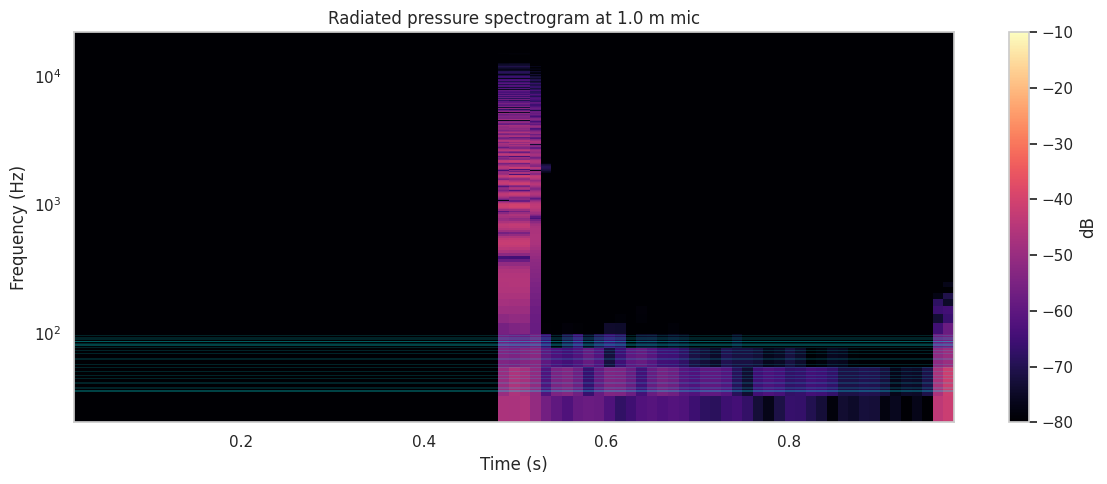

In [10]:
sr = PARAMS["audio"]["sample_rate_hz"]
pre_s = PARAMS["audio"]["pre_impact_s"]
post_s = PARAMS["audio"]["post_impact_s"]
total_dur = pre_s + post_s
t_target = np.linspace(0, total_dur, int(sr * total_dur))
sim_time = t_target - pre_s

interp_p = interp1d(t_sim, p_far_t, kind="cubic", bounds_error=False, fill_value=0.0)
audio_raw = interp_p(sim_time)
audio_raw[t_target < pre_s] = 0.0

# Calibrate to -1 dBFS peak (preserves shape, sets playback level)
peak_p = np.max(np.abs(audio_raw))
audio_norm = audio_raw / peak_p * 10**(PARAMS["audio"]["peak_dbfs"] / 20) if peak_p > 0 else audio_raw

audio_int16 = np.int16(audio_norm * 32767)
wav_path = FIG_DIR / "05-radiated-audio.wav"
mp3_path = FIG_DIR / "05-radiated-audio.mp3"
wavfile.write(str(wav_path), sr, audio_int16)
console.print(f"[green]wrote[/green] {wav_path} ({wav_path.stat().st_size} bytes)")

ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()
subprocess.run(
    [ffmpeg, "-y", "-loglevel", "error", "-i", str(wav_path),
     "-codec:a", "libmp3lame", "-qscale:a", "2", str(mp3_path)],
    check=True,
)
console.print(f"[green]wrote[/green] {mp3_path} ({mp3_path.stat().st_size} bytes)")

# Spectrogram
f_spec, t_spec, Sxx = spectrogram(audio_norm, fs=sr, nperseg=2048, noverlap=1536,
                                    scaling="spectrum")
Sxx_db = 10 * np.log10(np.maximum(Sxx, 1e-12))
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.pcolormesh(t_spec, f_spec, Sxx_db, shading="auto", cmap="magma",
                    vmin=-80, vmax=-10)
ax.set_yscale("log"); ax.set_ylim(20, sr/2)
ax.set_xlabel("Time (s)"); ax.set_ylabel("Frequency (Hz)")
ax.set_title(f"Radiated pressure spectrogram at {r_mic} m mic")
fig.colorbar(im, ax=ax, label="dB")
for f in freqs_p:
    ax.axhline(f, color="cyan", alpha=0.2, lw=0.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "05-radiated-spectrogram.png", dpi=140, bbox_inches="tight")
plt.show()

display(Audio(str(wav_path), rate=sr))